# Chlorophyll-a (Chla) Prediction : updated Bidirectional LSTM

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['axes.grid'] = True

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TF version:", tf.__version__)


TF version: 2.20.0


## 2. Load Data

In [22]:
try:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    DATA_PATH = 'updated_data.csv'

df = pd.read_csv(DATA_PATH)

# Keep only rows without missing values, preserve chronological order
df = df.dropna().reset_index(drop=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Saving updated_data.csv to updated_data (1).csv
Shape: (808, 22)
Columns: ['time', 'chla', 'fe', 'NO3', 'PO4', 'sea_surface_temperature_anomaly', 'silicate', 'O2', 'Salinity', 'uo', 'vo', 'wo', 'spC02', 'ph', 'chla_log', 'month', 'doy', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'kd(light)']


,time,chla,fe,NO3,PO4,sea_surface_temperature_anomaly,silicate,O2,Salinity,uo,...,spC02,ph,chla_log,month,doy,month_sin,month_cos,doy_sin,doy_cos,kd(light)
0,15-11-2023,0.339529,0.001766,28.127596,0.000854,0.355932,66.023960,216.79845,23.269981,0.066488,...,29.223454,8.155942,0.292318,11,319,-0.5,0.866025,-0.711657,0.702527,0.046792
1,16-11-2023,0.294218,0.001574,21.586666,0.001641,0.563978,51.700134,213.13123,24.965141,-0.043050,...,30.073938,8.138963,0.257907,11,320,-0.5,0.866025,-0.699458,0.714673,0.052440
2,17-11-2023,0.239607,0.001255,14.680003,0.000476,0.712240,30.622130,211.46613,28.803804,0.275142,...,32.184574,8.105216,0.214794,11,321,-0.5,0.866025,-0.687053,0.726608,0.066645
3,18-11-2023,0.186493,0.001101,12.298223,0.000221,0.752516,22.906878,211.24419,28.447226,-0.186735,...,33.534630,8.086390,0.171002,11,322,-0.5,0.866025,-0.674444,0.738326,0.060290
4,19-11-2023,0.194990,0.001227,15.153887,0.000307,0.719782,30.938460,211.88050,29.099293,-0.341118,...,34.079000,8.076333,0.178138,11,323,-0.5,0.866025,-0.661635,0.749826,0.047619


In [3]:
print("Start Date:", df['time'].min())
print("End Date:  ", df['time'].max())


Start Date: 2023-11-15
End Date:   2026-01-31


## 3. Quick EDA

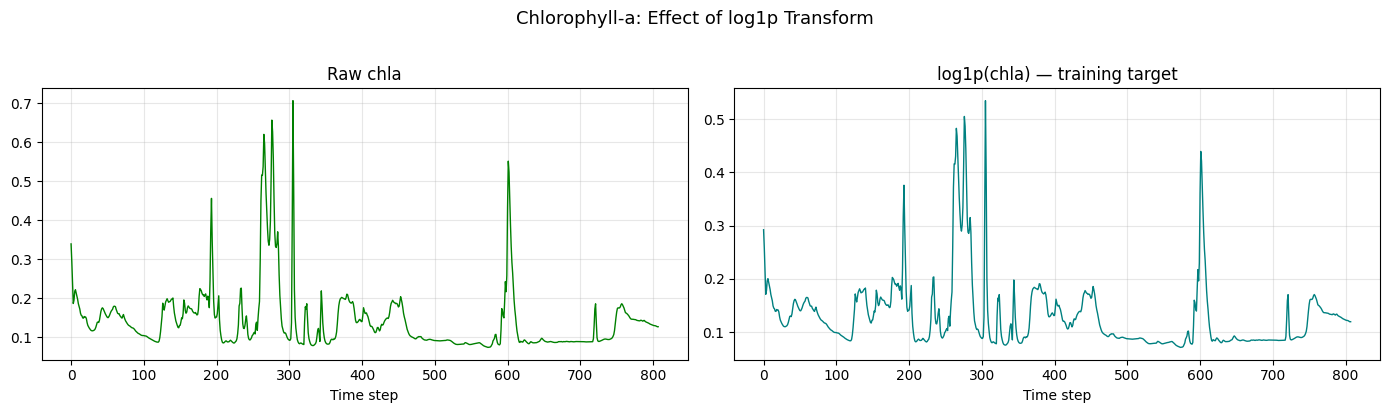

In [23]:
#raw chla vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df['chla'],     color='green', lw=1); axes[0].set_title('Raw chla')
axes[1].plot(df['chla_log'], color='teal',  lw=1); axes[1].set_title('log1p(chla) — training target')
for ax in axes:
    ax.set_xlabel('Time step'); ax.grid(True, alpha=0.3)
plt.suptitle('Chlorophyll-a: Effect of log1p Transform', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 4. Correlation Heatmap

In [5]:
TARGET_COL = 'chla_log'

# Exclude leakage / redundant columns from the correlation scan itself
EXCLUDE = ['time', 'chla', 'chla_log_lag1', 'chla_log_lag2', 'chla_log_lag3', TARGET_COL]
candidate_features = [c for c in df.columns if c not in EXCLUDE]

corr_series = (
    df[candidate_features + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

print("=" * 50)
print(f"{'Feature':<40} {'Correlation':>10}")
print("=" * 50)
for feat, val in corr_series.items():
    marker = "  ◀ TOP-5" if feat in corr_series.head(5).index else ""
    print(f"{feat:<40} {val:>10.4f}{marker}")
print("=" * 50)


Feature                                  Correlation
NO3                                          0.4243  ◀ TOP-5
kd(light)                                    0.4009  ◀ TOP-5
sea_surface_temperature_anomaly             -0.1792  ◀ TOP-5
O2                                           0.1487  ◀ TOP-5
PO4                                          0.1450  ◀ TOP-5
uo                                           0.1282
month_sin                                   -0.1067
spC02                                       -0.1055
fe                                           0.0993
Salinity                                    -0.0956
silicate                                     0.0841
doy_sin                                     -0.0798
doy_cos                                     -0.0642
ph                                           0.0566
month                                        0.0517
doy                                          0.0494
month_cos                                   -0.0308
vo                

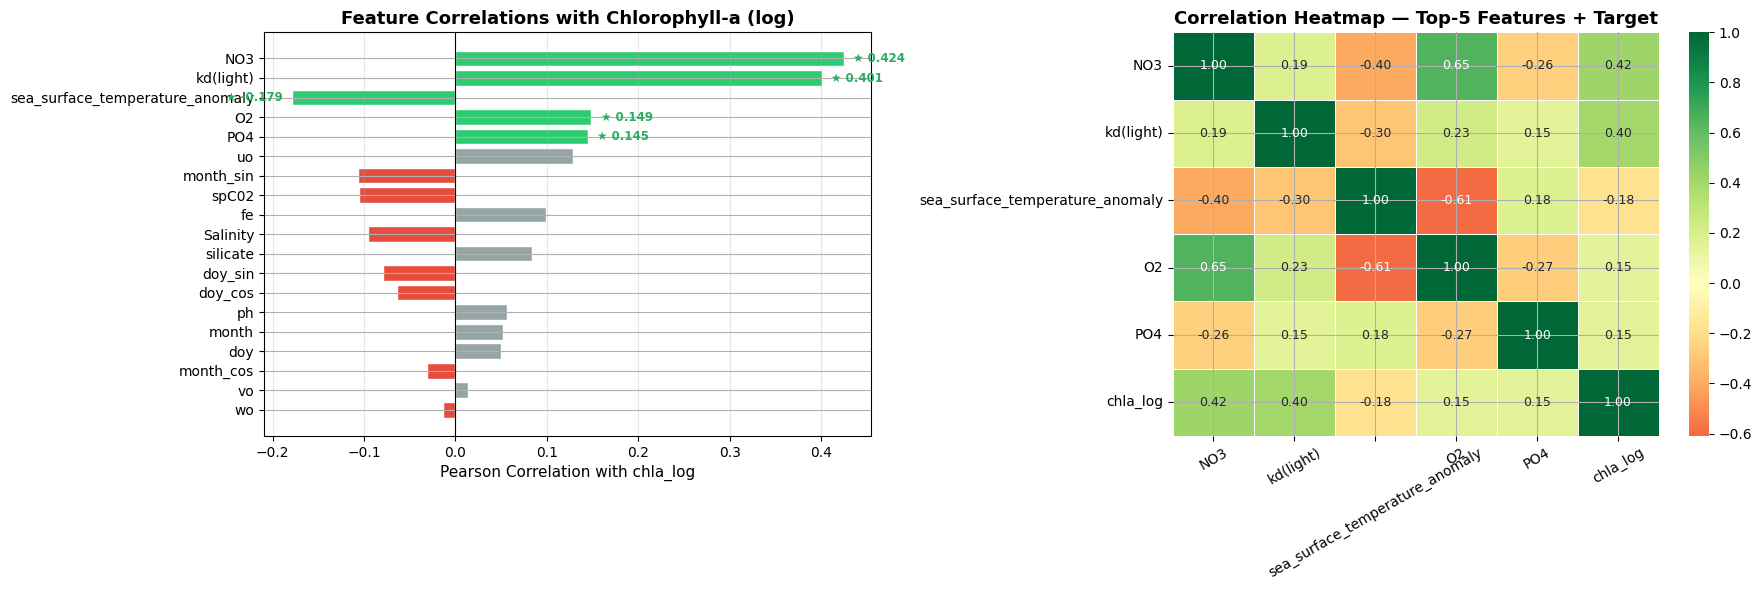

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
colors = ['#2ecc71' if i < 5 else ('#e74c3c' if v < 0 else '#95a5a6')
          for i, v in enumerate(corr_series.values)]
bars = ax.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with chla_log', fontsize=11)
ax.set_title('Feature Correlations with Chlorophyll-a (log)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

top5 = corr_series.head(5).index.tolist()
for bar, feat, val in zip(bars[::-1], corr_series.index, corr_series.values):
    if feat in top5:
        ax.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
                f'★ {val:.3f}', va='center',
                ha='left' if val >= 0 else 'right',
                fontsize=8.5, color='#27ae60', fontweight='bold')

ax2 = axes[1]
heatmap_cols = top5 + [TARGET_COL]
corr_matrix = df[heatmap_cols].corr()
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax2,
    annot_kws={'size': 9}
)
ax2.set_title('Correlation Heatmap — Top-5 Features + Target', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 5. Feature Selection



In [7]:
assert 'chla_log' in df.columns, "chla_log column missing from CSV!"
print("chla_log stats:")
print(df['chla_log'].describe())

X_columns = [
    'fe', 'NO3', 'kd(light)', 'PO4',
    'sea_surface_temperature_anomaly',
    'silicate', 'O2', 'Salinity',
    'uo', 'vo', 'wo',
    'spC02', 'ph',
    'month_sin', 'month_cos',
    'doy_sin', 'doy_cos',
]
y_column = ['chla_log']

missing = [c for c in X_columns + y_column if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

print(f"\nFeature count: {len(X_columns)}")
print("Features:", X_columns)


chla_log stats:
count    808.000000
mean       0.130587
std        0.066233
min        0.071251
25%        0.085754
50%        0.113497
75%        0.150663
max        0.534894
Name: chla_log, dtype: float64

Feature count: 17
Features: ['fe', 'NO3', 'kd(light)', 'PO4', 'sea_surface_temperature_anomaly', 'silicate', 'O2', 'Salinity', 'uo', 'vo', 'wo', 'spC02', 'ph', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']


## 6. Chronological Train / Validation / Test Split



In [8]:
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)   # train+val = 85%, last 15% held out as test

print(f"Total rows : {n}")
print(f"Train rows : {n_train}   ({df['time'].iloc[0]} -> {df['time'].iloc[n_train-1]})")
print(f"Val rows   : {n_val - n_train}   ({df['time'].iloc[n_train]} -> {df['time'].iloc[n_val-1]})")
print(f"Test rows  : {n - n_val}   ({df['time'].iloc[n_val]} -> {df['time'].iloc[n-1]})")


Total rows : 808
Train rows : 565   (2023-11-15 -> 2025-06-02)
Val rows   : 121   (2025-06-03 -> 2025-10-01)
Test rows  : 122   (2025-10-02 -> 2026-01-31)


## 7. Scale Features

**Fix:** `MinMaxScaler` is fit using **training rows only**. We then apply that
already-fitted scaler to the *entire* chronological series (train+val+test together)
so that the look-back windowing in the next step has continuous context across the
split boundaries — this does not leak any val/test information into the scaler itself,
since its min/max parameters came only from the training rows.

In [9]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaler.fit(df[X_columns].iloc[:n_train])
y_scaler.fit(df[y_column].iloc[:n_train])

X_all_scaled = X_scaler.transform(df[X_columns])
y_all_scaled = y_scaler.transform(df[y_column])

scaled_df = pd.DataFrame(
    np.hstack((X_all_scaled, y_all_scaled)),
    columns=X_columns + y_column
)
n_features = scaled_df.shape[1]

print("Scaled DataFrame shape:", scaled_df.shape)
scaled_df.head()


Scaled DataFrame shape: (808, 18)


,fe,NO3,kd(light),PO4,sea_surface_temperature_anomaly,silicate,O2,Salinity,uo,vo,wo,spC02,ph,month_sin,month_cos,doy_sin,doy_cos,chla_log
0,0.351525,1.000000,0.425533,0.005658,0.548996,1.000000,0.628777,0.526343,0.537927,0.942872,0.449232,0.149906,0.836486,0.25,0.933013,0.144168,0.851261,0.471834
1,0.302028,0.767356,0.569365,0.011126,0.602188,0.774506,0.518738,0.613050,0.451196,0.943701,0.192481,0.210956,0.734977,0.25,0.933013,0.150268,0.857334,0.396910
2,0.219676,0.521703,0.931176,0.003035,0.640094,0.442684,0.468774,0.809395,0.703138,0.369834,0.466561,0.362463,0.533223,0.25,0.933013,0.156470,0.863301,0.303040
3,0.179997,0.436990,0.769320,0.001263,0.650391,0.321225,0.462115,0.791157,0.337427,1.000000,0.574846,0.459374,0.420669,0.25,0.933013,0.162775,0.869161,0.207690
4,0.212618,0.538558,0.446581,0.001856,0.642022,0.447663,0.481208,0.824509,0.215188,0.737013,0.577312,0.498450,0.360547,0.25,0.933013,0.169180,0.874911,0.223227


## 8. Convert to Supervised (Windowed) Learning Format

In [10]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    """
    Frame a time series as a supervised learning dataset.
    data   : DataFrame or ndarray of shape (samples, features)
    n_in   : number of lag time steps to use as input
    n_out  : number of future steps to predict
    Returns: DataFrame with lagged inputs + forecast outputs
    """
    n_vars = 1 if type(data) is list else data.shape[1]
    df_in  = pd.DataFrame(data)
    cols, names = [], []

    for i in range(n_in, 0, -1):
        cols.append(df_in.shift(i))
        names += [f'var{j+1}(t-{i})' for j in range(n_vars)]

    for i in range(n_out):
        cols.append(df_in.shift(-i))
        if i == 0:
            names += [f'var{j+1}(t)' for j in range(n_vars)]
        else:
            names += [f'var{j+1}(t+{i})' for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg


def build_windowed_splits(n_lags):
    """
    Window the full scaled series once (for continuity across split boundaries),
    then split the *windowed* rows by which split their target timestamp falls in.
    No val/test target is ever used to fit anything upstream of this point.
    """
    reframed_ = series_to_supervised(scaled_df, n_in=n_lags, n_out=1)
    n_obs_ = n_lags * n_features
    target_name = f'var{n_features}(t)'

    idx = reframed_.index
    tr_idx = idx[idx < n_train]
    va_idx = idx[(idx >= n_train) & (idx < n_val)]
    te_idx = idx[idx >= n_val]

    def xy(sel_idx):
        sub = reframed_.loc[sel_idx]
        X_ = sub.values[:, :n_obs_].reshape(-1, n_lags, n_features)
        y_ = sub[target_name].values
        return X_, y_

    return xy(tr_idx), xy(va_idx), xy(te_idx), reframed_


## 9. Tune the Look-back Window (`N_LAGS`)


In [11]:
def build_quick_model(input_shape, units=32):
    m = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(units, recurrent_dropout=0.1, kernel_regularizer=l2(1e-4))),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

lag_candidates = [3, 5, 7, 10, 14, 21]
lag_results = []

for lag in lag_candidates:
    (tr_X, tr_y), (va_X, va_y), _, _ = build_windowed_splits(lag)

    tf.keras.utils.set_random_seed(SEED)
    quick_model = build_quick_model((lag, n_features))
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)

    quick_model.fit(
        tr_X, tr_y,
        validation_data=(va_X, va_y),
        epochs=60, batch_size=32,
        shuffle=False, verbose=0,
        callbacks=[es]
    )

    val_pred = quick_model.predict(va_X, verbose=0).flatten()
    val_r2 = r2_score(va_y, val_pred)
    lag_results.append((lag, val_r2))
    print(f"N_LAGS={lag:>2}  ->  val R² = {val_r2:.4f}")

best_lag = max(lag_results, key=lambda t: t[1])[0]
print(f"\nBest look-back window: N_LAGS = {best_lag}")


N_LAGS= 3  ->  val R² = 0.8270
N_LAGS= 5  ->  val R² = 0.7965


N_LAGS= 7  ->  val R² = 0.7621
N_LAGS=10  ->  val R² = 0.7595
N_LAGS=14  ->  val R² = 0.7647
N_LAGS=21  ->  val R² = 0.6971

Best look-back window: N_LAGS = 3


## 10. Build Final Train / Val Test Tensors

In [12]:
N_LAGS = best_lag

(train_X, train_y), (val_X, val_y), (test_X, test_y), reframed = build_windowed_splits(N_LAGS)

print("train_X:", train_X.shape, "| train_y:", train_y.shape)
print("val_X  :", val_X.shape,   "| val_y  :", val_y.shape)
print("test_X :", test_X.shape,  "| test_y :", test_y.shape)


train_X: (562, 3, 18) | train_y: (562,)
val_X  : (121, 3, 18) | val_y  : (121,)
test_X : (122, 3, 18) | test_y : (122,)


## 11. Build the BiLSTM Model

In [13]:
def create_model(input_shape, lstm_units=64, dense_units=16, l2_reg=1e-4,
                  dropout=0.2, recurrent_dropout=0.1, lr=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(lstm_units, recurrent_dropout=recurrent_dropout,
                            kernel_regularizer=l2(l2_reg))),
        Dropout(dropout),
        Dense(dense_units, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    model.summary()
    return model

tf.keras.utils.set_random_seed(SEED)
model = create_model((train_X.shape[1], train_X.shape[2]))


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 128)            │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,577 (174.13 KB)

 Trainable params: 44,577 (174.13 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Callbacks (watch validation, not test)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)


## 13. Train the Model

In [15]:
history = model.fit(
    train_X, train_y,
    epochs=200,
    batch_size=32,
    validation_data=(val_X, val_y),   # <-- true validation set, NOT the test set
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False    # keep temporal order
)


Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0410 - mae: 0.1405 - val_loss: 0.0256 - val_mae: 0.0867 - learning_rate: 0.0010
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0385 - mae: 0.1202 - val_loss: 0.0332 - val_mae: 0.1408 - learning_rate: 0.0010
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0238 - mae: 0.0831 - val_loss: 0.0267 - val_mae: 0.1141 - learning_rate: 0.0010
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0222 - mae: 0.0793 - val_loss: 0.0258 - val_mae: 0.1125 - learning_rate: 0.0010
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0201 - mae: 0.0738 - val_loss: 0.0250 - val_mae: 0.1110 - learning_rate: 0.0010
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0191 - mae: 0.0721 - val_loss: 0.0208 - val_mae: 0.0913 - learning_rate: 0.0010
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0176 - mae: 0.0684 - val_loss: 0.0192 - val_mae: 0.0850 - learning_rate: 0.0010
Epoch 

## 14. Training History

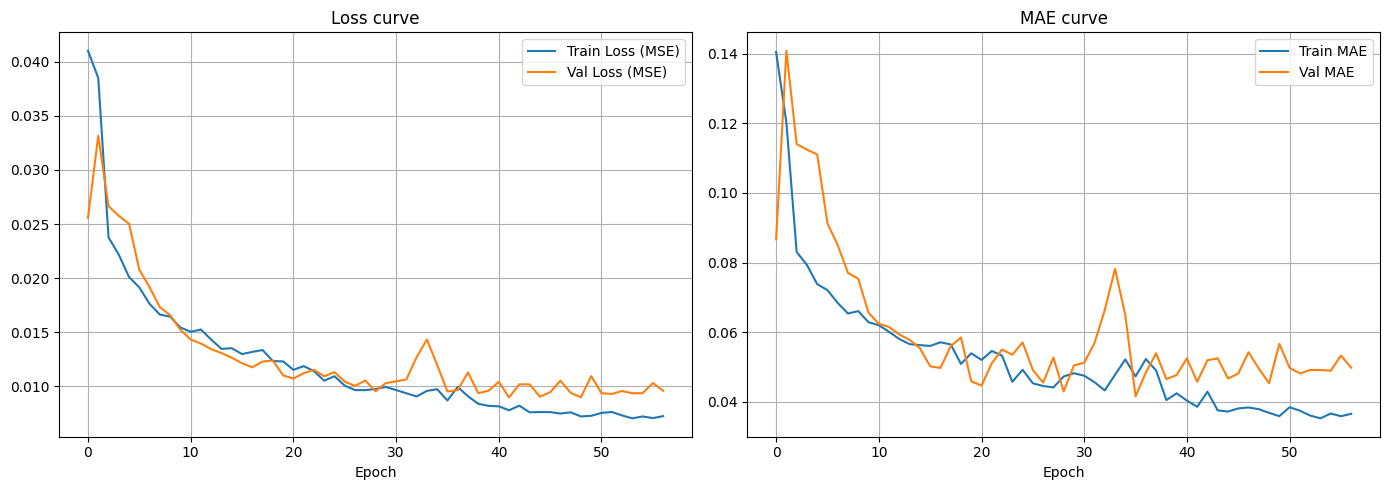

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 15. Evaluate on the Held-out Test Set (scaled space)

In [18]:
predictions = model.predict(test_X, verbose=0).flatten()

mae  = mean_absolute_error(test_y, predictions)
rmse = sqrt(mean_squared_error(test_y, predictions))
r2   = r2_score(test_y, predictions)

print(f"Test MAE  (scaled): {mae:.4f}")
print(f"Test RMSE (scaled): {rmse:.4f}")
print(f"Test R²   (scaled): {r2:.4f}")


Test MAE  (scaled): 0.0218
Test RMSE (scaled): 0.0297
Test R²   (scaled): 0.7606


## 16. Inverse Transform — Log(chla) and Raw chla (mg/m³)

In [19]:
# Back to log(chla) space
inv_predictions = y_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
inv_test_y      = y_scaler.inverse_transform(test_y.reshape(-1, 1)).flatten()

mae_log  = mean_absolute_error(inv_test_y, inv_predictions)
rmse_log = sqrt(mean_squared_error(inv_test_y, inv_predictions))
r2_log   = r2_score(inv_test_y, inv_predictions)

print(f"Test MAE  (log-chla): {mae_log:.4f}")
print(f"Test RMSE (log-chla): {rmse_log:.4f}")
print(f"Test R²   (log-chla): {r2_log:.4f}")

raw_pred = np.expm1(inv_predictions)
raw_true = np.expm1(inv_test_y)

mae_raw  = mean_absolute_error(raw_true, raw_pred)
rmse_raw = sqrt(mean_squared_error(raw_true, raw_pred))
r2_raw   = r2_score(raw_true, raw_pred)

print(f"\nTest MAE  (raw chla, mg/m³): {mae_raw:.4f}")
print(f"Test RMSE (raw chla, mg/m³): {rmse_raw:.4f}")
print(f"Test R²   (raw chla, mg/m³): {r2_raw:.4f}")


Test MAE  (log-chla): 0.0100
Test RMSE (log-chla): 0.0136
Test R²   (log-chla): 0.7606

Test MAE  (raw chla, mg/m³): 0.0113
Test RMSE (raw chla, mg/m³): 0.0155
Test R²   (raw chla, mg/m³): 0.7567


## 18. Actual vs Predicted Plots (BiLSTM, log-chla)

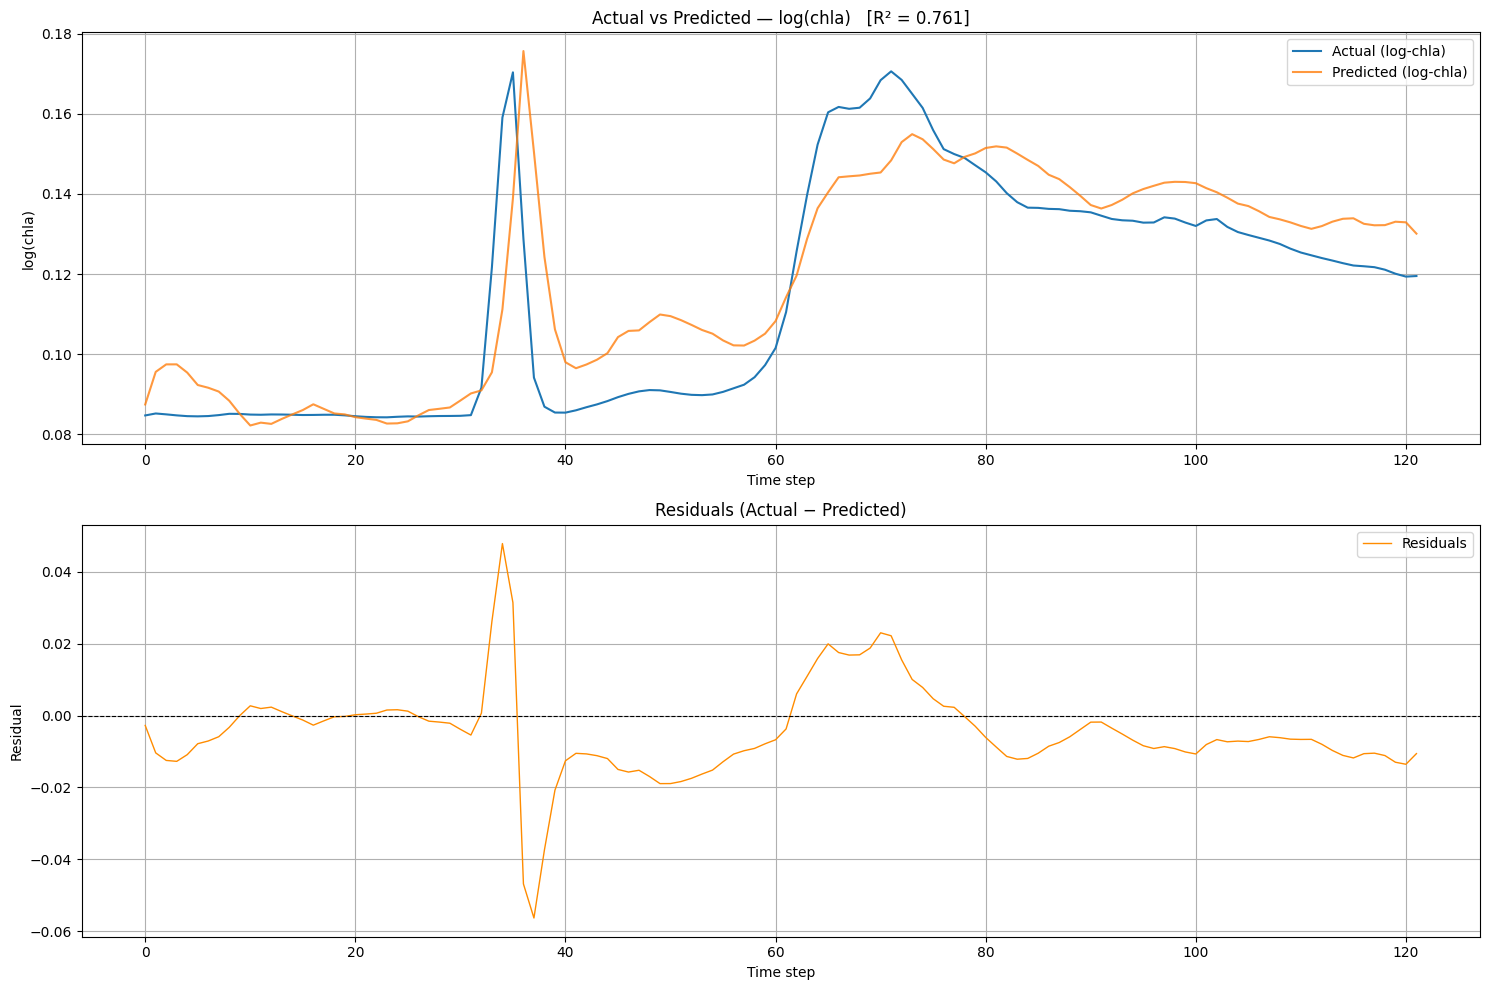

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(inv_test_y,      label='Actual (log-chla)',    linewidth=1.5)
axes[0].plot(inv_predictions, label='Predicted (log-chla)', linewidth=1.5, alpha=0.8)
axes[0].set_title(f'Actual vs Predicted — log(chla)   [R² = {r2_log:.3f}]')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('log(chla)')
axes[0].legend()

residuals = inv_test_y - inv_predictions
axes[1].plot(residuals, color='darkorange', linewidth=1, label='Residuals')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Residuals (Actual − Predicted)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Residual')
axes[1].legend()

plt.tight_layout()
plt.show()


## 19. Scatter: Actual vs Predicted

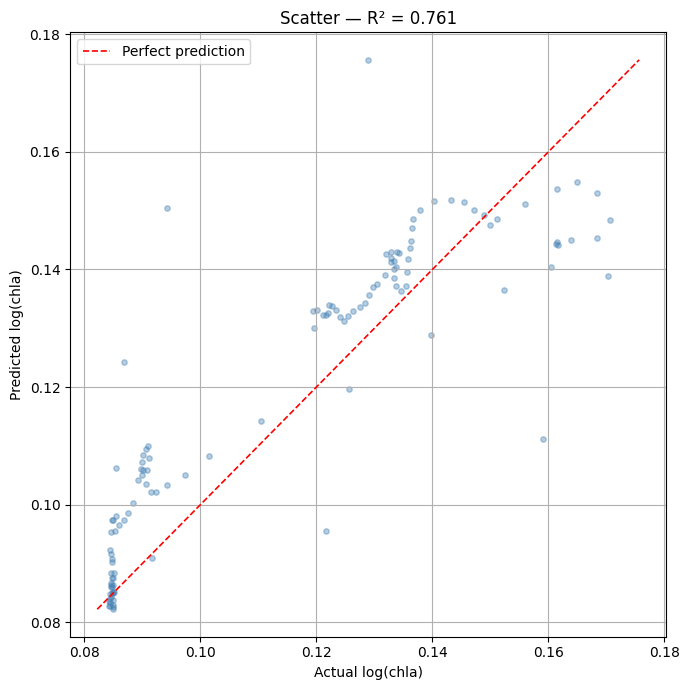

In [21]:
plt.figure(figsize=(7, 7))
plt.scatter(inv_test_y, inv_predictions, alpha=0.4, s=15, color='steelblue')
lims = [min(inv_test_y.min(), inv_predictions.min()),
        max(inv_test_y.max(), inv_predictions.max())]
plt.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
plt.xlabel('Actual log(chla)')
plt.ylabel('Predicted log(chla)')
plt.title(f'Scatter — R² = {r2_log:.3f}')
plt.legend()
plt.tight_layout()
plt.show()
